# Pokemon Legendary Status Prediction

In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('pokemon.csv')
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [6]:
print(df.shape)

(800, 13)


In [7]:
print(df.columns)

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')


In [8]:
print(df.dtypes)

#              int64
Name          object
Type 1        object
Type 2        object
Total          int64
HP             int64
Attack         int64
Defense        int64
Sp. Atk        int64
Sp. Def        int64
Speed          int64
Generation     int64
Legendary       bool
dtype: object


In [9]:
print(df.isnull().sum())

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64


In [11]:
print(df.describe())

                #      Total          HP      Attack     Defense     Sp. Atk  \
count  800.000000  800.00000  800.000000  800.000000  800.000000  800.000000   
mean   362.813750  435.10250   69.258750   79.001250   73.842500   72.820000   
std    208.343798  119.96304   25.534669   32.457366   31.183501   32.722294   
min      1.000000  180.00000    1.000000    5.000000    5.000000   10.000000   
25%    184.750000  330.00000   50.000000   55.000000   50.000000   49.750000   
50%    364.500000  450.00000   65.000000   75.000000   70.000000   65.000000   
75%    539.250000  515.00000   80.000000  100.000000   90.000000   95.000000   
max    721.000000  780.00000  255.000000  190.000000  230.000000  194.000000   

          Sp. Def       Speed  Generation  
count  800.000000  800.000000   800.00000  
mean    71.902500   68.277500     3.32375  
std     27.828916   29.060474     1.66129  
min     20.000000    5.000000     1.00000  
25%     50.000000   45.000000     2.00000  
50%     70.0000

In [12]:
categorical_cols = ['Name', 'Type 1', 'Type 2']

numerical_cols = [
    '#', 'Total', 'HP', 'Attack', 'Defense',
    'Sp. Atk', 'Sp. Def', 'Speed', 'Generation'
]

In [13]:
print(df['Legendary'].value_counts())

Legendary
False    735
True      65
Name: count, dtype: int64


In [17]:
X = df.drop('Legendary', axis=1)
y = df['Legendary']

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
# First, fit the preprocessor on the original X_train (DataFrame)
preprocessor.fit(X_train)

# Then, transform X_train before applying SMOTE
X_train_processed_for_smote = preprocessor.transform(X_train)

# Apply SMOTE to the preprocessed training data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed_for_smote, y_train)

print("Original training set distribution:")
print(y_train.value_counts())
print("\nResampled training set distribution after SMOTE:")
print(y_train_resampled.value_counts())

Original training set distribution:
Legendary
False    588
True      52
Name: count, dtype: int64

Resampled training set distribution after SMOTE:
Legendary
False    588
True     588
Name: count, dtype: int64


In [21]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    oob_score =True,
    max_samples=0.8,
)

In [22]:
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
)

In [54]:
bagging_pipeline = Pipeline([
    ('model', bagging_model)
])

In [55]:
boosting_pipeline = Pipeline([
    ('model', boosting_model)
])

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [26]:
param_dist_bagging = {
    'model__n_estimators': [50, 100, 150, 200]
}

param_dist_boosting = {
    'model__n_estimators': [50, 100, 150, 200],
    'model__learning_rate': [0.3, 0.4, 0.1, 0.2] # Learning rate for AdaBoostClassifier
}

In [59]:
random_search_bagging = RandomizedSearchCV(
    estimator=bagging_pipeline,
    param_distributions=param_dist_bagging,
    n_iter=10,
    cv=cv,
    scoring='accuracy',
    random_state=42
)

# Fit on resampled data (preprocessed for SMOTE, but X_train here means original features for pipeline preprocessing)
random_search_bagging.fit(X_train_resampled, y_train_resampled)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('model',
                                              BaggingClassifier(estimator=DecisionTreeClassifier(),
                                                                max_samples=0.8,
                                                                oob_score=True,
                                                                random_state=42))]),
                   param_distributions={'model__n_estimators': [50, 100, 150,
                                                                200]},
                   random_state=42, scoring='accuracy')

In [60]:
random_search_boosting = RandomizedSearchCV(
    estimator=boosting_pipeline,
    param_distributions=param_dist_boosting,
    n_iter=10,
    cv=cv,
    scoring='accuracy',
    random_state=42
)

# Fit on resampled data (preprocessed for SMOTE, but X_train here means original features for pipeline preprocessing)
random_search_boosting.fit(X_train_resampled, y_train_resampled)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('model',
                                              AdaBoostClassifier(estimator=DecisionTreeClassifier(),
                                                                 random_state=42))]),
                   param_distributions={'model__learning_rate': [0.3, 0.4, 0.1,
                                                                 0.2],
                                        'model__n_estimators': [50, 100, 150,
                                                                200]},
                   random_state=42, scoring='accuracy')

In [61]:
# Preprocess X_test using the already fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

bagging_pred = random_search_bagging.predict(X_test_processed)
boosting_pred = random_search_boosting.predict(X_test_processed)

In [62]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Define the individual models for the VotingClassifier
model1 = LogisticRegression(random_state=42, solver='liblinear') # Added solver for consistency and suppressed warning
model2 = RandomForestClassifier(random_state=42)
model3 = KNeighborsClassifier()

# Create the VotingClassifier
voting_model = VotingClassifier(
    estimators=[('lr', model1), ('rf', model2), ('kn', model3)],
    voting='soft' # 'soft' voting uses predicted probabilities
)

# Create a pipeline for the VotingClassifier (without preprocessor, as data is already processed)
voting_pipeline = Pipeline([
    ('model', voting_model)
])

# Fit the VotingClassifier pipeline using the SMOTE-resampled training data
voting_pipeline.fit(X_train_resampled, y_train_resampled)

# Make predictions on the preprocessed test data using X_test_processed
voting_pred = voting_pipeline.predict(X_test_processed)

In [63]:
from sklearn.ensemble import StackingClassifier

# Define base estimators (can be the same as or different from VotingClassifier)
estimators = [
    ('lr', LogisticRegression(random_state=42, solver='liblinear')),
    ('rf', RandomForestClassifier(random_state=42)),
    ('knn', KNeighborsClassifier())
]

# Define the final estimator
final_estimator = RandomForestClassifier(random_state=42)

# Create the StackingClassifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=cv, # Use the defined StratifiedKFold for cross-validation
    n_jobs=-1, # Use all available cores
    passthrough=True # Pass original features to the final estimator
)

# Create a pipeline for the StackingClassifier (without preprocessor, as data is already processed)
stacking_pipeline = Pipeline([
    ('model', stacking_model)
])

# Fit the StackingClassifier pipeline using the SMOTE-resampled training data
stacking_pipeline.fit(X_train_resampled, y_train_resampled)

# Make predictions on the preprocessed test data using X_test_processed
stacking_pred = stacking_pipeline.predict(X_test_processed)

In [64]:
bagging_acc = accuracy_score(y_test, bagging_pred)
boosting_acc = accuracy_score(y_test, boosting_pred)
stacking_acc = accuracy_score(y_test, stacking_pred)
voting_acc = accuracy_score(y_test, voting_pred)

print('Bagging Accuracy:', bagging_acc)
print('Boosting Accuracy:', boosting_acc)
print(f"Stacking Accuracy: {stacking_acc}")
print(f"Voting Accuracy: {voting_acc}")

Bagging Accuracy: 0.94375
Boosting Accuracy: 0.93125
Stacking Accuracy: 0.94375
Voting Accuracy: 0.925


In [65]:
bagging_recall = recall_score(y_test, bagging_pred)
boosting_recall = recall_score(y_test, boosting_pred)
stacking_recall = recall_score(y_test, stacking_pred)
voting_recall = recall_score(y_test, voting_pred)

print('Bagging Recall:', bagging_recall)
print('Boosting Recall:', boosting_recall)
print(f"Stacking Recall: {stacking_recall}")
print(f"Voting Recall: {voting_recall}")

Bagging Recall: 0.8461538461538461
Boosting Recall: 0.6923076923076923
Stacking Recall: 0.5384615384615384
Voting Recall: 0.8461538461538461


In [66]:
print(confusion_matrix(y_test, bagging_pred))
print(confusion_matrix(y_test, boosting_pred))
print(confusion_matrix(y_test, stacking_pred))
print(confusion_matrix(y_test, voting_pred))

[[140   7]
 [  2  11]]
[[140   7]
 [  4   9]]
[[144   3]
 [  6   7]]
[[137  10]
 [  2  11]]


In [67]:
print(classification_report(y_test, bagging_pred))

              precision    recall  f1-score   support

       False       0.99      0.95      0.97       147
        True       0.61      0.85      0.71        13

    accuracy                           0.94       160
   macro avg       0.80      0.90      0.84       160
weighted avg       0.96      0.94      0.95       160



In [36]:
print(classification_report(y_test, boosting_pred))

              precision    recall  f1-score   support

       False       0.96      0.95      0.95       147
        True       0.47      0.54      0.50        13

    accuracy                           0.91       160
   macro avg       0.71      0.74      0.73       160
weighted avg       0.92      0.91      0.92       160



In [37]:
print(classification_report(y_test, stacking_pred))

              precision    recall  f1-score   support

       False       0.96      0.96      0.96       147
        True       0.54      0.54      0.54        13

    accuracy                           0.93       160
   macro avg       0.75      0.75      0.75       160
weighted avg       0.93      0.93      0.93       160



In [38]:
print(classification_report(y_test, voting_pred))

              precision    recall  f1-score   support

       False       0.95      0.98      0.97       147
        True       0.67      0.46      0.55        13

    accuracy                           0.94       160
   macro avg       0.81      0.72      0.76       160
weighted avg       0.93      0.94      0.93       160



In [68]:
# Ensure X_test_processed is available from the previous step
bagging_prob = random_search_bagging.predict_proba(X_test_processed)[:,1]
boosting_prob = random_search_boosting.predict_proba(X_test_processed)[:,1]
voting_prob = voting_pipeline.predict_proba(X_test_processed)[:, 1]
stacking_prob = stacking_pipeline.predict_proba(X_test_processed)[:, 1]

In [72]:
bagging_roc_auc = roc_auc_score(y_test, bagging_prob)
boosting_roc_auc = roc_auc_score(y_test, boosting_prob)
voting_roc_auc = roc_auc_score(y_test, voting_prob)
stacking_roc_auc = roc_auc_score(y_test, stacking_prob)

# Calculate FPR and FNR from confusion matrices based on predictions
# Bagging
cm_bagging = confusion_matrix(y_test, bagging_pred)
tn_bagging, fp_bagging, fn_bagging, tp_bagging = cm_bagging.ravel()
fpr_bagging = fp_bagging / (fp_bagging + tn_bagging)
fnr_bagging = fn_bagging / (fn_bagging + tp_bagging)

# Boosting
cm_boosting = confusion_matrix(y_test, boosting_pred)
tn_boosting, fp_boosting, fn_boosting, tp_boosting = cm_boosting.ravel()
fpr_boosting = fp_boosting / (fp_boosting + tn_boosting)
fnr_boosting = fn_boosting / (fn_boosting + tp_boosting)

# Stacking
cm_stacking = confusion_matrix(y_test, stacking_pred)
tn_stacking, fp_stacking, fn_stacking, tp_stacking = cm_stacking.ravel()
fpr_stacking = fp_stacking / (fp_stacking + tn_stacking)
fnr_stacking = fn_stacking / (fn_stacking + tp_stacking)

# Voting
cm_voting = confusion_matrix(y_test, voting_pred)
tn_voting, fp_voting, fn_voting, tp_voting = cm_voting.ravel()
fpr_voting = fp_voting / (fp_voting + tn_voting)
fnr_voting = fn_voting / (fn_voting + tp_voting)

print(f"Bagging ROC-AUC: {bagging_roc_auc:.4f}, FPR: {fpr_bagging:.4f}, FNR: {fnr_bagging:.4f}")
print(f"Boosting ROC-AUC: {boosting_roc_auc:.4f}, FPR: {fpr_boosting:.4f}, FNR: {fnr_boosting:.4f}")
print(f"Stacking ROC-AUC: {stacking_roc_auc:.4f}, FPR: {fpr_stacking:.4f}, FNR: {fnr_stacking:.4f}")
print(f"Voting ROC-AUC: {voting_roc_auc:.4f}, FPR: {fpr_voting:.4f}, FNR: {fnr_voting:.4f}")

Bagging ROC-AUC: 0.9647, FPR: 0.0476, FNR: 0.1538
Boosting ROC-AUC: 0.8223, FPR: 0.0476, FNR: 0.3077
Stacking ROC-AUC: 0.9649, FPR: 0.0204, FNR: 0.4615
Voting ROC-AUC: 0.9649, FPR: 0.0680, FNR: 0.1538


In [69]:
fpr1, tpr1, _ = roc_curve(y_test, bagging_prob)
fpr2, tpr2, _ = roc_curve(y_test, boosting_prob)
fpr3, tpr3, _ = roc_curve(y_test, voting_prob)
fpr4, tpr4, _ = roc_curve(y_test, stacking_prob)

### ROC Curve for Bagging and Boosting

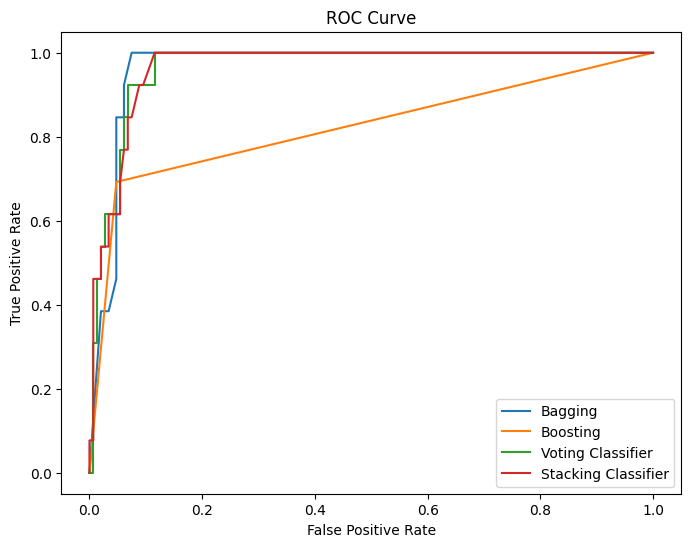

In [70]:
plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, label='Bagging')
plt.plot(fpr2, tpr2, label='Boosting')
plt.plot(fpr3, tpr3, label='Voting Classifier')
plt.plot(fpr4, tpr4, label='Stacking Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

### Performance Comparison Table

In [74]:
data = {
    'Model': ['Bagging', 'Boosting', 'Stacking', 'Voting'],
    'Accuracy': [bagging_acc, boosting_acc, stacking_acc, voting_acc],
    'Recall': [bagging_recall, boosting_recall, stacking_recall, voting_recall],
    'ROC-AUC': [bagging_roc_auc, boosting_roc_auc, stacking_roc_auc, voting_roc_auc],
    'FPR': [fpr_bagging, fpr_boosting, fpr_stacking, fpr_voting],
    'FNR': [fnr_bagging, fnr_boosting, fnr_stacking, fnr_voting]
}
full_comparison = pd.DataFrame(data)
display(full_comparison)

,Model,Accuracy,Recall,ROC-AUC,FPR,FNR
0,Bagging,0.94375,0.846154,0.964678,0.047619,0.153846
1,Boosting,0.93125,0.692308,0.822344,0.047619,0.307692
2,Stacking,0.94375,0.538462,0.964940,0.020408,0.461538
3,Voting,0.92500,0.846154,0.964940,0.068027,0.153846
